In [1]:


!pip install requests beautifulsoup4 wordcloud matplotlib scikit-learn nltk

import requests
from bs4 import BeautifulSoup
import re
import os
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
def scrape_page(url):
    """
    Fetches and parses a single URL.
    Returns cleaned English-only plain text.
    Removes boilerplate, scripts, styles, navigation elements.
    """
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()
    except Exception as e:
        print(f"[SKIP] Could not fetch {url}: {e}")
        return ""

    soup = BeautifulSoup(response.text, "html.parser")

    # Remove non-content tags: scripts, styles, nav, footer, header
    for tag in soup(["script", "style", "nav", "footer", "header", "noscript", "form"]):
        tag.decompose()

    text = soup.get_text(separator=" ")

    # Remove lines that are too short (boilerplate / menu items)
    lines = [line.strip() for line in text.splitlines()]
    lines = [line for line in lines if len(line) > 20]

    text = " ".join(lines)

    # Keep only ASCII / basic English characters; drop Hindi/Devanagari and other scripts
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [3]:


URLS = [
    # 1. Main / About
    "https://www.iitj.ac.in/main/en/iitj",
    "https://www.iitj.ac.in/main/en/introduction",

    # 2. Academics (departments, programmes)
    "https://www.iitj.ac.in/m/Index/main-departments?lg=en",
    "https://www.iitj.ac.in/chemical-engineering/",
    "https://www.iitj.ac.in/computer-science-engineering/",
    "https://www.iitj.ac.in/electrical-engineering/",
    "https://www.iitj.ac.in/mechanical-engineering/",
    "https://www.iitj.ac.in/m/Index/main-schools?lg=en",
    "https://www.iitj.ac.in/school-of-artificial-intelligence-data-science/en/school-of-artificial-intelligence-and-data-science",
    "https://www.iitj.ac.in/school-of-design/",
    "https://www.iitj.ac.in/m/Index/main-programs?lg=en",
    "https://www.iitj.ac.in/Bachelor-of-Technology/en/Bachelor-of-Technology",
    "https://www.iitj.ac.in/office-of-academics/en/academics",

    # 3. Research
    "https://www.iitj.ac.in/office-of-research-development/en/office-of-research-and-development",
    "https://www.iitj.ac.in/main/en/research-highlight",

    # 4. Faculty
    "https://www.iitj.ac.in/main/en/faculty-members",
    "https://www.iitj.ac.in/People/List?dept=computer-science-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",

    # 5. Students / Admissions (academic regulations context)
    "https://www.iitj.ac.in/office-of-students/en/office-of-students",
    "https://iitj.ac.in/office-of-academics/en/academic-regulations",

    # 6. Announcements / Highlights
    "https://www.iitj.ac.in/main/en/all-announcement",

    #7. Curriculum
    "https://iitj.ac.in/Office-of-Academics/en/B.Tech.-Computer-Science-Engineering",
]


raw_documents = []
for url in URLS:
    print(f"Scraping: {url}")
    text = scrape_page(url)
    if text:
        raw_documents.append(text)
        print(f"  -> {len(text.split())} words collected")
    else:
        print(f"  -> Empty/failed")

print(f"\nTotal documents collected: {len(raw_documents)}")

Scraping: https://www.iitj.ac.in/main/en/iitj
  -> 450 words collected
Scraping: https://www.iitj.ac.in/main/en/introduction
  -> 212 words collected
Scraping: https://www.iitj.ac.in/m/Index/main-departments?lg=en
  -> 70 words collected
Scraping: https://www.iitj.ac.in/chemical-engineering/
  -> 524 words collected
Scraping: https://www.iitj.ac.in/computer-science-engineering/
  -> 665 words collected
Scraping: https://www.iitj.ac.in/electrical-engineering/
  -> 534 words collected
Scraping: https://www.iitj.ac.in/mechanical-engineering/
  -> 565 words collected
Scraping: https://www.iitj.ac.in/m/Index/main-schools?lg=en
  -> 69 words collected
Scraping: https://www.iitj.ac.in/school-of-artificial-intelligence-data-science/en/school-of-artificial-intelligence-and-data-science
  -> 218 words collected
Scraping: https://www.iitj.ac.in/school-of-design/
  -> 466 words collected
Scraping: https://www.iitj.ac.in/m/Index/main-programs?lg=en
  -> 67 words collected
Scraping: https://www.iitj

In [4]:
STOPWORDS = set(stopwords.words('english'))

CUSTOM_STOPWORDS = {
    "iit", "jodhpur", "iitj", "click", "home", "page", "menu",
    "nav", "link", "read", "more", "view", "all", "also", "us",
    "may", "would", "could", "shall", "one", "two", "three",
    "back", "next", "previous", "www", "http", "https", "en",
    "main", "index", "lg", "ac", "in", "st", "nd", "rd", "th", "must",
    "redirecttologinpage"
}

ALL_STOPWORDS = STOPWORDS | CUSTOM_STOPWORDS


TERM_MAP = {
    "b.tech": "btech",
    "m.tech": "mtech",
    "b.sc": "bsc",
    "m.sc": "msc",
    "m.b.a": "mba",
    "ph.d": "phd",
    "ph.d.": "phd",
    "b.tech.": "btech",
    "m.tech.": "mtech",
    "p.g": "pg",
    "u.g": "ug",
    "m.phil" : "mphil",
}
# -------------------------------------------------------------------------

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Lowercase
    text = text.lower()

    # ---- ADDED: replace compound terms BEFORE punctuation removal ----
    for term, replacement in TERM_MAP.items():
        text = text.replace(term, replacement)
    # ------------------------------------------------------------------

    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove digits and punctuation — keep only alphabets and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords, boilerplate words, and very short tokens
    tokens = [
        t for t in tokens
        if t not in ALL_STOPWORDS
        and len(t) > 2
    ]

    # Lemmatize each token to its base dictionary form
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens


tokenized_documents = [preprocess(doc) for doc in raw_documents]

all_tokens = [token for doc in tokenized_documents for token in doc]
vocab = set(all_tokens)

print("=" * 40)
print("DATASET STATISTICS")
print("=" * 40)
print(f"Total documents       : {len(tokenized_documents)}")
print(f"Total tokens          : {len(all_tokens)}")
print(f"Vocabulary size       : {len(vocab)}")
print(f"Top 20 frequent words : {Counter(all_tokens).most_common(20)}")

DATASET STATISTICS
Total documents       : 21
Total tokens          : 12782
Vocabulary size       : 2297
Top 20 frequent words : [('student', 407), ('course', 228), ('academic', 177), ('semester', 158), ('program', 153), ('phd', 152), ('degree', 135), ('mtech', 128), ('engineering', 123), ('requirement', 120), ('credit', 115), ('department', 108), ('institute', 98), ('programme', 96), ('grade', 91), ('research', 86), ('science', 78), ('minimum', 69), ('btech', 66), ('dual', 63)]


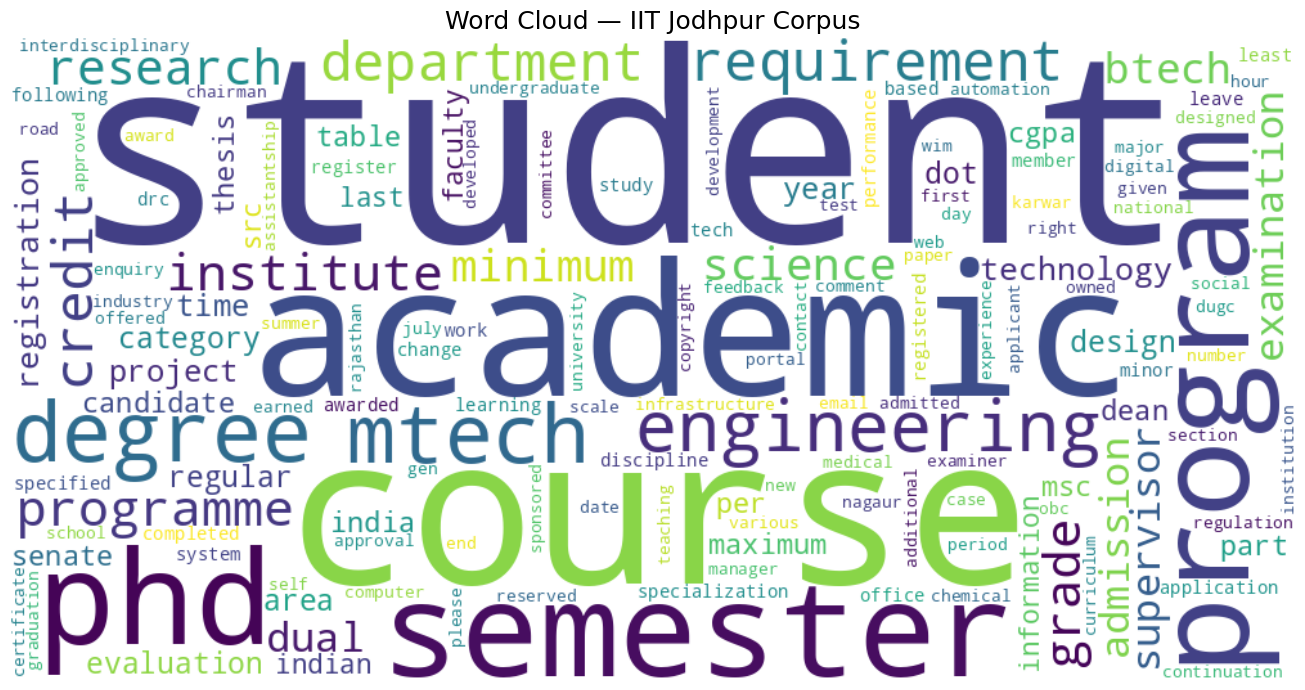

Word cloud saved as wordcloud.png


In [5]:
word_freq = Counter(all_tokens)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=150,
    colormap='viridis'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — IIT Jodhpur Corpus", fontsize=18)
plt.tight_layout()
plt.savefig("wordcloud.png", dpi=150)
plt.show()
print("Word cloud saved as wordcloud.png")

In [6]:
with open("cleaned_corpus.txt", "w") as f:
    for doc_tokens in tokenized_documents:
        # Write each document as a single line
        f.write(" ".join(doc_tokens) + "\n")

print(f"Cleaned corpus saved to cleaned_corpus.txt")
print(f"Total lines (documents): {len(tokenized_documents)}")

Cleaned corpus saved to cleaned_corpus.txt
Total lines (documents): 21


In [7]:
MIN_COUNT = 2

freq = Counter(all_tokens)
vocab_words = [w for w, c in freq.items() if c >= MIN_COUNT]
vocab_size   = len(vocab_words)

word2idx = {w: i for i, w in enumerate(vocab_words)}
idx2word = {i: w for w, i in word2idx.items()}

# Filter tokenized documents to only vocab words
filtered_docs = [
    [w for w in doc if w in word2idx]
    for doc in tokenized_documents
]

print(f"Vocabulary size (min_count={MIN_COUNT}): {vocab_size}")
print(f"Sample vocab: {vocab_words[:20]}")

Vocabulary size (min_count=2): 1307
Sample vocab: ['indian', 'institute', 'technology', 'established', 'foster', 'education', 'research', 'india', 'committed', 'technological', 'thought', 'action', 'benefit', 'economic', 'development', 'scholarship', 'teaching', 'learning', 'creative', 'accomplishment']


In [8]:
def build_neg_table(word2idx, freq, vocab_words, table_size=1_000_000, power=0.75):
    """
    Build a large lookup table for fast negative sampling.
    Words are sampled proportional to freq(w)^0.75 (Mikolov et al.).
    """
    counts = np.array([freq[w] for w in vocab_words], dtype=np.float64)
    counts = counts ** power
    counts /= counts.sum()

    table = np.zeros(table_size, dtype=np.int32)
    idx = 0
    cumulative = 0.0
    for i, p in enumerate(counts):
        cumulative += p
        while idx < table_size and idx / table_size < cumulative:
            table[idx] = i
            idx += 1

    np.random.shuffle(table)
    return table

neg_table = build_neg_table(word2idx, freq, vocab_words)
print(f"Negative sampling table built. Size: {len(neg_table):,}")

Negative sampling table built. Size: 1,000,000


In [9]:
def generate_skipgram_pairs(filtered_docs, word2idx, window):
    """
    Yield (center_idx, context_idx) pairs for Skip-gram training.
    """
    pairs = []
    for doc in filtered_docs:
        indices = [word2idx[w] for w in doc if w in word2idx]
        for i, center in enumerate(indices):
            lo = max(0, i - window)
            hi = min(len(indices), i + window + 1)
            for j in range(lo, hi):
                if j != i:
                    pairs.append((center, indices[j]))
    return pairs


def generate_cbow_pairs(filtered_docs, word2idx, window):
    """
    Yield (context_indices_list, target_idx) pairs for CBOW training.
    """
    pairs = []
    for doc in filtered_docs:
        indices = [word2idx[w] for w in doc if w in word2idx]
        for i, target in enumerate(indices):
            lo = max(0, i - window)
            hi = min(len(indices), i + window + 1)
            context = [indices[j] for j in range(lo, hi) if j != i]
            if context:
                pairs.append((context, target))
    return pairs

In [10]:
def sigmoid(x):
    """Numerically stable sigmoid."""
    return np.where(x >= 0,
                    1 / (1 + np.exp(-x)),
                    np.exp(x) / (1 + np.exp(x)))

In [11]:
class SkipGram:
    """
    Skip-gram Word2Vec trained with Negative Sampling.

    Architecture
    ─────────────
    • W_in  : (vocab_size × vector_size)  — input  / embedding matrix
    • W_out : (vocab_size × vector_size)  — output / context matrix

    Training objective (per positive pair):
        maximise  log σ(v_c · v̂_w)
               +  Σ_{k=1}^{K} log σ(−v_{nk} · v̂_w)

    where v̂_w = W_in[center], v_c = W_out[context],
    and {nk} are K negative samples drawn from the noise distribution.
    """

    def __init__(self, vocab_size, vector_size=100, window=5,
                 neg_samples=5, lr=0.025, epochs=10, seed=42):
        self.vocab_size   = vocab_size
        self.vector_size  = vector_size
        self.window       = window
        self.neg_samples  = neg_samples
        self.lr           = lr
        self.epochs       = epochs

        rng = np.random.default_rng(seed)
        # Xavier-style initialisation
        scale = 0.5 / vector_size
        self.W_in  = rng.uniform(-scale, scale, (vocab_size, vector_size))
        self.W_out = np.zeros((vocab_size, vector_size))

    def train(self, filtered_docs, neg_table):
        pairs = generate_skipgram_pairs(filtered_docs, word2idx, self.window)
        print(f"  [Skip-gram] {len(pairs):,} training pairs")

        for epoch in range(self.epochs):
            np.random.shuffle(pairs)
            total_loss = 0.0

            for center_idx, ctx_idx in pairs:
                v_center = self.W_in[center_idx]          # (D,)

                # ── Positive sample ──────────────────────────────────────
                v_ctx_pos = self.W_out[ctx_idx]           # (D,)
                score_pos  = sigmoid(v_ctx_pos @ v_center)
                grad_pos   = (1 - score_pos)              # gradient w.r.t. score

                total_loss -= np.log(score_pos + 1e-10)

                # ── Negative samples ─────────────────────────────────────
                neg_idxs = neg_table[
                    np.random.randint(0, len(neg_table), self.neg_samples)
                ]
                v_neg     = self.W_out[neg_idxs]          # (K, D)
                scores_neg = sigmoid(v_neg @ v_center)    # (K,)
                grad_neg   = -scores_neg                  # gradient w.r.t. scores

                total_loss -= np.sum(np.log(1 - scores_neg + 1e-10))

                # ── Accumulate gradient for W_in ─────────────────────────
                dW_in = (grad_pos * v_ctx_pos
                         + grad_neg @ v_neg)              # (D,)  — chain rule

                # ── Update W_out ─────────────────────────────────────────
                self.W_out[ctx_idx]  += self.lr * grad_pos * v_center
                self.W_out[neg_idxs] += self.lr * grad_neg[:, None] * v_center

                # ── Update W_in ──────────────────────────────────────────
                self.W_in[center_idx] += self.lr * dW_in

            avg_loss = total_loss / len(pairs)
            print(f"  Epoch {epoch+1:>2}/{self.epochs}  loss = {avg_loss:.4f}")

        print("  [Skip-gram] Training complete.")

    def most_similar(self, word, topn=5):
        """Return topn most similar words by cosine similarity (using W_in)."""
        if word not in word2idx:
            return f"'{word}' not in vocabulary"
        idx = word2idx[word]
        query = self.W_in[idx]
        norms = np.linalg.norm(self.W_in, axis=1) + 1e-10
        sims  = (self.W_in @ query) / (np.linalg.norm(query) * norms)
        sims[idx] = -1  # exclude the word itself
        top_idxs = np.argsort(sims)[::-1][:topn]
        return [(idx2word[i], float(sims[i])) for i in top_idxs]

    def analogy(self, a, b, c, topn=3):
        """
        Solve: a : b :: c : ?
        result ≈ W_in[b] - W_in[a] + W_in[c]
        """
        missing = [w for w in [a, b, c] if w not in word2idx]
        if missing:
            return f"Words not in vocab: {missing}"
        va = self.W_in[word2idx[a]]
        vb = self.W_in[word2idx[b]]
        vc = self.W_in[word2idx[c]]
        query = vb - va + vc
        norms  = np.linalg.norm(self.W_in, axis=1) + 1e-10
        sims   = (self.W_in @ query) / (np.linalg.norm(query) * norms)
        # Exclude input words
        for w in [a, b, c]:
            sims[word2idx[w]] = -1
        top_idxs = np.argsort(sims)[::-1][:topn]
        return [(idx2word[i], float(sims[i])) for i in top_idxs]

    def get_vector(self, word):
        """Return embedding vector for a word."""
        if word not in word2idx:
            return None
        return self.W_in[word2idx[word]]

In [12]:
class CBOW:
    """
    Continuous Bag-of-Words Word2Vec trained with Negative Sampling.

    Architecture
    ─────────────
    • W_in  : (vocab_size × vector_size)  — input / context embeddings
    • W_out : (vocab_size × vector_size)  — output / target embeddings

    Forward pass:
        h = mean( W_in[c] for c in context_words )   — context average

    Training objective:
        maximise  log σ(W_out[target] · h)
               +  Σ_{k=1}^{K} log σ(−W_out[nk] · h)
    """

    def __init__(self, vocab_size, vector_size=100, window=5,
                 neg_samples=5, lr=0.025, epochs=10, seed=42):
        self.vocab_size   = vocab_size
        self.vector_size  = vector_size
        self.window       = window
        self.neg_samples  = neg_samples
        self.lr           = lr
        self.epochs       = epochs

        rng = np.random.default_rng(seed)
        scale = 0.5 / vector_size
        self.W_in  = rng.uniform(-scale, scale, (vocab_size, vector_size))
        self.W_out = np.zeros((vocab_size, vector_size))

    def train(self, filtered_docs, neg_table):
        pairs = generate_cbow_pairs(filtered_docs, word2idx, self.window)
        print(f"  [CBOW] {len(pairs):,} training pairs")

        for epoch in range(self.epochs):
            np.random.shuffle(pairs)
            total_loss = 0.0

            for ctx_idxs, target_idx in pairs:
                # ── Forward: average context embeddings ───────────────────
                ctx_vecs = self.W_in[ctx_idxs]            # (|C|, D)
                h        = ctx_vecs.mean(axis=0)          # (D,)

                # ── Positive sample ───────────────────────────────────────
                v_target  = self.W_out[target_idx]        # (D,)
                score_pos  = sigmoid(v_target @ h)
                grad_pos   = (1 - score_pos)

                total_loss -= np.log(score_pos + 1e-10)

                # ── Negative samples ──────────────────────────────────────
                neg_idxs  = neg_table[
                    np.random.randint(0, len(neg_table), self.neg_samples)
                ]
                v_neg      = self.W_out[neg_idxs]         # (K, D)
                scores_neg = sigmoid(v_neg @ h)           # (K,)
                grad_neg   = -scores_neg

                total_loss -= np.sum(np.log(1 - scores_neg + 1e-10))

                # ── Gradient w.r.t. h ─────────────────────────────────────
                dh = (grad_pos * v_target
                      + grad_neg @ v_neg)                 # (D,)

                # ── Update W_out ──────────────────────────────────────────
                self.W_out[target_idx]  += self.lr * grad_pos * h
                self.W_out[neg_idxs]    += self.lr * grad_neg[:, None] * h

                # ── Update W_in: distribute gradient to each context word ─
                dW_in = dh / len(ctx_idxs)               # (D,)  mean gradient
                for ci in ctx_idxs:
                    self.W_in[ci] += self.lr * dW_in

            avg_loss = total_loss / len(pairs)
            print(f"  Epoch {epoch+1:>2}/{self.epochs}  loss = {avg_loss:.4f}")

        print("  [CBOW] Training complete.")

    def most_similar(self, word, topn=5):
        """Return topn most similar words by cosine similarity (using W_in)."""
        if word not in word2idx:
            return f"'{word}' not in vocabulary"
        idx   = word2idx[word]
        query = self.W_in[idx]
        norms = np.linalg.norm(self.W_in, axis=1) + 1e-10
        sims  = (self.W_in @ query) / (np.linalg.norm(query) * norms)
        sims[idx] = -1
        top_idxs = np.argsort(sims)[::-1][:topn]
        return [(idx2word[i], float(sims[i])) for i in top_idxs]

    def analogy(self, a, b, c, topn=3):
        """Solve: a : b :: c : ?"""
        missing = [w for w in [a, b, c] if w not in word2idx]
        if missing:
            return f"Words not in vocab: {missing}"
        va = self.W_in[word2idx[a]]
        vb = self.W_in[word2idx[b]]
        vc = self.W_in[word2idx[c]]
        query = vb - va + vc
        norms  = np.linalg.norm(self.W_in, axis=1) + 1e-10
        sims   = (self.W_in @ query) / (np.linalg.norm(query) * norms)
        for w in [a, b, c]:
            sims[word2idx[w]] = -1
        top_idxs = np.argsort(sims)[::-1][:topn]
        return [(idx2word[i], float(sims[i])) for i in top_idxs]

    def get_vector(self, word):
        if word not in word2idx:
            return None
        return self.W_in[word2idx[word]]

In [13]:
import time

HYPERPARAMS = [
    {"vector_size": 50,  "window": 3, "neg_samples": 5},
    {"vector_size": 100, "window": 5, "neg_samples": 5},
    {"vector_size": 100, "window": 5, "neg_samples": 10},
    {"vector_size": 200, "window": 7, "neg_samples": 10},
]

EPOCHS = 20
LR     = 0.025

cbow_models     = []
skipgram_models = []

print(f"{'Model':<12} {'Dim':>5} {'Win':>5} {'Neg':>5} {'Time(s)':>10}")
print("-" * 45)

for hp in HYPERPARAMS:
    dim = hp["vector_size"]
    win = hp["window"]
    neg = hp["neg_samples"]

    # ── CBOW ────────────────────────────────────────────────────────
    print(f"\nTraining CBOW  (dim={dim}, win={win}, neg={neg}) ...")
    t0   = time.time()
    cbow = CBOW(
        vocab_size=vocab_size,
        vector_size=dim,
        window=win,
        neg_samples=neg,
        lr=LR,
        epochs=EPOCHS,
        seed=42
    )
    cbow.train(filtered_docs, neg_table)
    t_cbow = time.time() - t0
    cbow_models.append((hp, cbow))
    print(f"{'CBOW':<12} {dim:>5} {win:>5} {neg:>5} {t_cbow:>10.2f}")

    # ── Skip-gram ────────────────────────────────────────────────────
    print(f"\nTraining Skip-gram (dim={dim}, win={win}, neg={neg}) ...")
    t0 = time.time()
    sg = SkipGram(
        vocab_size=vocab_size,
        vector_size=dim,
        window=win,
        neg_samples=neg,
        lr=LR,
        epochs=EPOCHS,
        seed=42
    )
    sg.train(filtered_docs, neg_table)
    t_sg = time.time() - t0
    skipgram_models.append((hp, sg))
    print(f"{'Skip-gram':<12} {dim:>5} {win:>5} {neg:>5} {t_sg:>10.2f}")

# Best model = last config (dim=200, win=7, neg=10)
best_cbow     = cbow_models[-1][1]
best_skipgram = skipgram_models[-1][1]

# Save embeddings as numpy arrays
np.save("cbow_best_W_in.npy",     best_cbow.W_in)
np.save("skipgram_best_W_in.npy", best_skipgram.W_in)
print("\nBest model embeddings saved.")

Model          Dim   Win   Neg    Time(s)
---------------------------------------------

Training CBOW  (dim=50, win=3, neg=5) ...
  [CBOW] 11,792 training pairs
  Epoch  1/20  loss = 4.1589
  Epoch  2/20  loss = 4.1586
  Epoch  3/20  loss = 4.1530
  Epoch  4/20  loss = 4.0672
  Epoch  5/20  loss = 3.7019
  Epoch  6/20  loss = 3.2791
  Epoch  7/20  loss = 3.0430
  Epoch  8/20  loss = 2.9211
  Epoch  9/20  loss = 2.8484
  Epoch 10/20  loss = 2.7951
  Epoch 11/20  loss = 2.7387
  Epoch 12/20  loss = 2.6752
  Epoch 13/20  loss = 2.6152
  Epoch 14/20  loss = 2.5531
  Epoch 15/20  loss = 2.4945
  Epoch 16/20  loss = 2.4356
  Epoch 17/20  loss = 2.3895
  Epoch 18/20  loss = 2.3447
  Epoch 19/20  loss = 2.3032
  Epoch 20/20  loss = 2.2689
  [CBOW] Training complete.
CBOW            50     3     5      48.39

Training Skip-gram (dim=50, win=3, neg=5) ...
  [Skip-gram] 70,500 training pairs
  Epoch  1/20  loss = 3.9917
  Epoch  2/20  loss = 2.9740
  Epoch  3/20  loss = 2.5673
  Epoch  4/20  los

In [14]:
# Print 200-dimensional embedding for 'btech'
word = "mtech"
vec = best_skipgram.get_vector(word)
if vec is not None:
    vec_str = ", ".join(f"{v:.4f}" for v in vec)
    print(f"{word} - {vec_str}")
else:
    print(f"'{word}' not found in vocabulary")

mtech - -0.0623, 0.0026, 0.3314, -0.5389, -0.0027, -0.1030, -0.1785, 0.1809, 0.0123, 0.3481, -0.0311, -0.1377, 0.0247, -0.4637, -0.0125, 0.0489, -0.3556, -0.0098, 0.2514, -0.3182, 0.0158, -0.2154, 0.2480, 0.1220, -0.5173, -0.3631, -0.2090, 0.1649, -0.1146, -0.0614, 0.0343, 0.1088, 0.2070, 0.1291, -0.0055, -0.2491, -0.4630, -0.3275, -0.1770, -0.0985, -0.3851, 0.0195, -0.3102, 0.1543, 0.1180, 0.2242, 0.3134, 0.3386, 0.3632, -0.0909, -0.2775, 0.0772, 0.1817, 0.1597, -0.1678, 0.0509, -0.0006, 0.0213, -0.2061, 0.2299, -0.4777, -0.0183, 0.0940, -0.1078, -0.2856, 0.1665, -0.0287, 0.1538, -0.2252, 0.2633, 0.5506, 0.1410, 0.2149, 0.3305, -0.1597, -0.0249, 0.3918, -0.0991, -0.2225, -0.4077, 0.0541, -0.1189, -0.1598, 0.1445, -0.4347, -0.0219, 0.2589, -0.1308, 0.2163, -0.5637, -0.3323, 0.6640, -0.0654, -0.0258, -0.5287, -0.0316, -0.2160, 0.1149, 0.0516, -0.2610, 0.0393, 0.0106, 0.4093, -0.1397, -0.2542, 0.0557, -0.1514, -0.0883, -0.3158, 0.0665, -0.1658, -0.2313, -0.1733, -0.0718, -0.1530, 0.0317,

In [15]:
QUERY_WORDS = ["research", "student", "phd", "exam"]

print("=" * 60)
print("TOP-5 NEAREST NEIGHBORS (Cosine Similarity)")
print("=" * 60)

for word in QUERY_WORDS:
    print(f"\nWord: '{word}'")
    print(f"  {'CBOW':<35} {'Skip-gram'}")
    print(f"  {'-'*55}")

    c_res = best_cbow.most_similar(word, topn=5)
    s_res = best_skipgram.most_similar(word, topn=5)

    if isinstance(c_res, str) or isinstance(s_res, str):
        print(f"  {str(c_res):<35} {str(s_res)}")
    else:
        for (cw, cs), (sw, ss) in zip(c_res, s_res):
            print(f"  {cw:<20} ({cs:.4f})    {sw:<20} ({ss:.4f})")


TOP-5 NEAREST NEIGHBORS (Cosine Similarity)

Word: 'research'
  CBOW                                Skip-gram
  -------------------------------------------------------
  prospective          (0.9867)    proposal             (0.5735)
  facilitates          (0.9818)    track                (0.5424)
  maybe                (0.9812)    conversant           (0.5399)
  provides             (0.9807)    foster               (0.5310)
  development          (0.9787)    ongoing              (0.5117)

Word: 'student'
  CBOW                                Skip-gram
  -------------------------------------------------------
  assigned             (0.9892)    arrangement          (0.5514)
  academic             (0.9853)    follows              (0.5449)
  end                  (0.9785)    extracurricular      (0.5362)
  semester             (0.9741)    administrative       (0.5282)
  cancellation         (0.9741)    whenever             (0.5266)

Word: 'phd'
  CBOW                                Skip-gra

In [16]:
def print_analogy(model, a, b, c, label, topn=3):
    print(f"  [{label}] {a} : {b} :: {c} : ?")
    res = model.analogy(a, b, c, topn=topn)
    if isinstance(res, str):
        print(f"    {res}")
    else:
        for word, score in res:
            print(f"      -> {word:<20} (score: {score:.4f})")

print("=" * 60)
print("ANALOGY EXPERIMENTS")
print("=" * 60)

print("\nAnalogy 1: undergraduate : btech :: postgraduate : ?")
print_analogy(best_cbow,     "undergraduate", "btech", "postgraduate", "CBOW")
print_analogy(best_skipgram, "undergraduate", "btech", "postgraduate", "Skip-gram")

print("\nAnalogy 2: professor : research :: student : ?")
print_analogy(best_cbow,     "professor", "research", "student", "CBOW")
print_analogy(best_skipgram, "professor", "research", "student", "Skip-gram")

print("\nAnalogy 3: minor : elective :: major : ?")
print_analogy(best_cbow,     "minor", "elective", "major", "CBOW")
print_analogy(best_skipgram, "minor", "elective", "major", "Skip-gram")

print("\nAnalogy 4: department : engineering :: school : ?")
print_analogy(best_cbow,     "department", "engineering", "school", "CBOW")
print_analogy(best_skipgram, "department", "engineering", "school", "Skip-gram")

ANALOGY EXPERIMENTS

Analogy 1: undergraduate : btech :: postgraduate : ?
  [CBOW] undergraduate : btech :: postgraduate : ?
      -> intelligent          (score: 0.9557)
      -> bachelor             (score: 0.9550)
      -> medicine             (score: 0.9360)
  [Skip-gram] undergraduate : btech :: postgraduate : ?
      -> parameterized        (score: 0.4659)
      -> nso                  (score: 0.4523)
      -> bouquet              (score: 0.4492)

Analogy 2: professor : research :: student : ?
  [CBOW] professor : research :: student : ?
      -> recommendation       (score: 0.9834)
      -> assigned             (score: 0.9809)
      -> approve              (score: 0.9787)
  [Skip-gram] professor : research :: student : ?
      -> quiz                 (score: 0.3789)
      -> proposal             (score: 0.3622)
      -> hostel               (score: 0.3564)

Analogy 3: minor : elective :: major : ?
  [CBOW] minor : elective :: major : ?
      -> adding               (score: 0.988

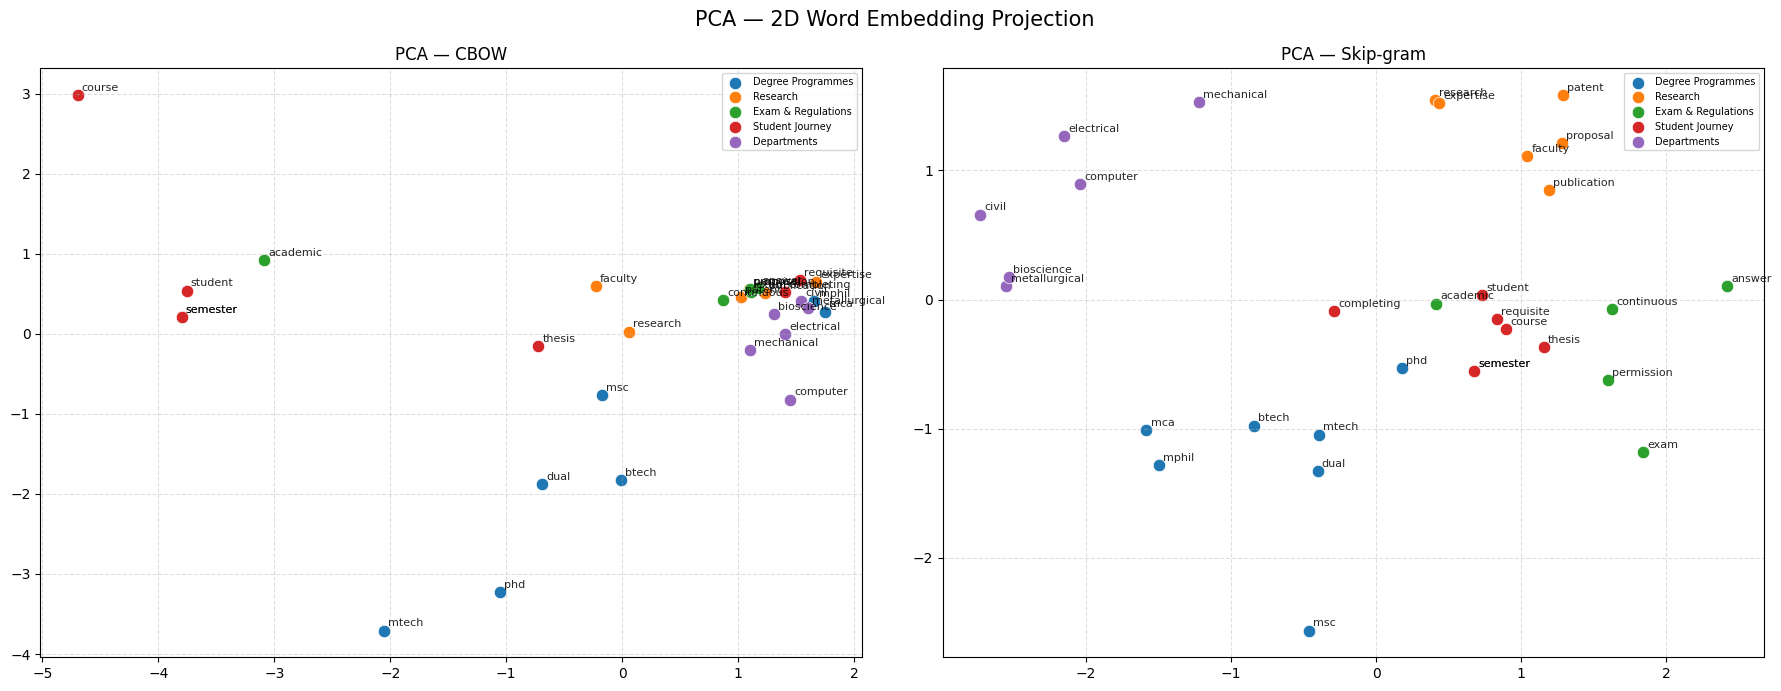

PCA visualization saved.


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


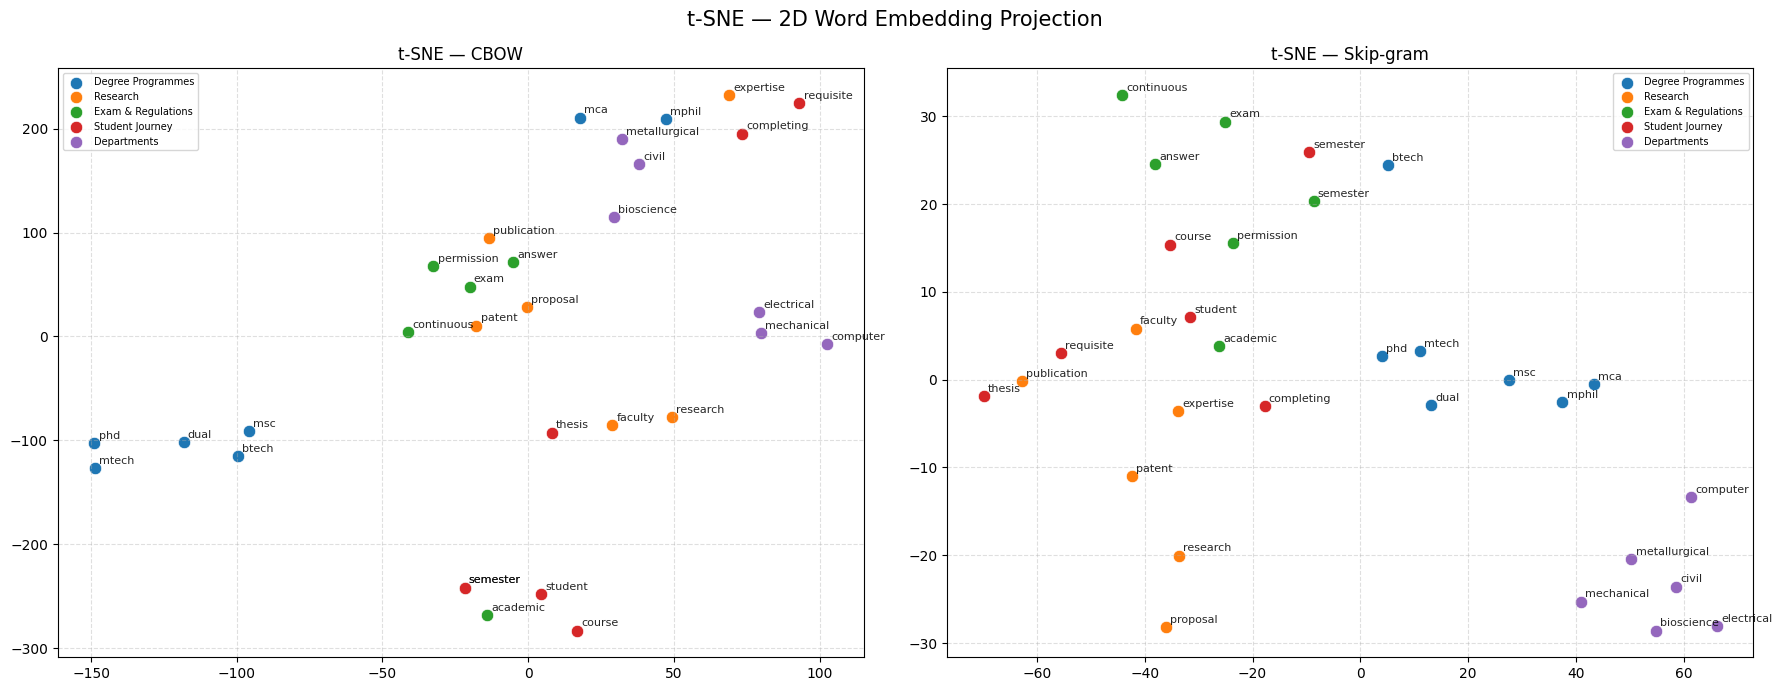

t-SNE visualization saved.


In [17]:
WORD_GROUPS = {
    "Degree Programmes": ["btech", "mtech", "phd", "msc", "mphil", "mca", "dual"],
    "Research":          ["research", "faculty", "patent", "proposal", "expertise", "publication"],
    "Exam & Regulations":["exam", "continuous", "answer", "permission", "semester", "academic"],
    "Student Journey":   ["student", "course", "thesis", "requisite", "semester", "completing"],
    "Departments":       ["computer", "civil", "mechanical", "electrical", "metallurgical", "bioscience"],
}

COLORS = {
    "Degree Programmes":  "#1f77b4",
    "Research":           "#ff7f0e",
    "Exam & Regulations": "#2ca02c",
    "Student Journey":    "#d62728",
    "Departments":        "#9467bd",
}

def collect_embeddings(model, word_groups):
    """Collect word vectors and their group labels, skipping OOV words."""
    words, vectors, labels = [], [], []
    for group, group_words in word_groups.items():
        for w in group_words:
            vec = model.get_vector(w)
            if vec is not None:
                words.append(w)
                vectors.append(vec)
                labels.append(group)
    return words, np.array(vectors), labels


def plot_embeddings(ax, words, vectors_2d, labels, title):
    """Scatter plot with per-group colour and word annotations."""
    plotted_groups = set()
    for word, vec, label in zip(words, vectors_2d, labels):
        color = COLORS[label]
        lbl   = label if label not in plotted_groups else "_nolegend_"
        plotted_groups.add(label)
        ax.scatter(vec[0], vec[1], c=color, s=80,
                   label=lbl, edgecolors="white", linewidths=0.5)
        ax.annotate(word, (vec[0], vec[1]),
                    fontsize=8, xytext=(3, 3),
                    textcoords="offset points", alpha=0.85)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, linestyle="--", alpha=0.4)


# ── PCA ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("PCA — 2D Word Embedding Projection", fontsize=15)

for ax, (model, arch) in zip(axes, [(best_cbow, "CBOW"),
                                     (best_skipgram, "Skip-gram")]):
    words, vecs, labels = collect_embeddings(model, WORD_GROUPS)
    if len(vecs) < 2:
        ax.set_title(f"PCA — {arch} (not enough words)")
        continue
    pca_2d = PCA(n_components=2, random_state=42).fit_transform(vecs)
    plot_embeddings(ax, words, pca_2d, labels, f"PCA — {arch}")

plt.tight_layout()
plt.savefig("pca_visualization.png", dpi=150)
plt.show()
print("PCA visualization saved.")


# ── t-SNE ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("t-SNE — 2D Word Embedding Projection", fontsize=15)

for ax, (model, arch) in zip(axes, [(best_cbow, "CBOW"),
                                     (best_skipgram, "Skip-gram")]):
    words, vecs, labels = collect_embeddings(model, WORD_GROUPS)
    if len(vecs) < 5:
        ax.set_title(f"t-SNE — {arch} (not enough words)")
        continue
    perp = min(5, len(vecs) - 1)
    tsne_2d = TSNE(n_components=2, perplexity=perp,
                   random_state=42, n_iter=1000).fit_transform(vecs)
    plot_embeddings(ax, words, tsne_2d, labels, f"t-SNE — {arch}")

plt.tight_layout()
plt.savefig("tsne_visualization.png", dpi=150)
plt.show()
print("t-SNE visualization saved.")